# Audit des donnees — Projet McGill IoT Cattle
**Date**: 2 avril 2026  
**Auteur**: Aliou Barry (UQAM)  
**Contexte**: Audit initial des 6 jeux de donnees CSV issus du depot GitHub de l'article Cellier et al. (2025)

## Objectifs de cet audit
1. Verifier la structure et la coherence des 6 fichiers CSV
2. Comparer les schemas de variables entre experiences
3. Identifier les problemes de qualite (manquants, doublons, incoherences)
4. Explorer le design experimental encode dans les donnees
5. Produire des visualisations exploratoires sur `Sum_Steps`
6. Formuler des questions precises pour la rencontre avec Tania et Marjorie

**Reference**: Cellier, M. et al. (2025). *Enhancing movement opportunity to support behavioral needs for movement-restricted cattle.* Sci Rep 15, 5917.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
pd.set_option('display.max_colwidth', 60)

sns.set_theme(style='whitegrid', palette='muted', font_scale=0.95)

DATA_DIR = Path('/Users/alioubarry/PROJECT/mcgill_iot_cattle/data-movement-behavior-main/dataset')
csv_files = sorted(DATA_DIR.glob('*.csv'))

print(f"Repertoire: {DATA_DIR}")
print(f"Fichiers trouves: {[p.name for p in csv_files]}")
print(f"Nombre de fichiers: {len(csv_files)}")

Repertoire: /Users/alioubarry/PROJECT/mcgill_iot_cattle/data-movement-behavior-main/dataset
Fichiers trouves: ['Fall2019.csv', 'Summer2019.csv', 'Summer2020.csv', 'Summer2021.csv', 'Winter2019.csv', 'Winter2020.csv']
Nombre de fichiers: 6


---
## 1. Chargement et vue d'ensemble

Les CSV sont separes par `;` (format europeen). Chaque fichier correspond a un essai experimental distinct.

In [4]:
datasets = {}
for path in csv_files:
    datasets[path.stem] = pd.read_csv(path, sep=';')

# Vue d'ensemble rapide
overview = []
for name, df in datasets.items():
    overview.append({
        'Essai': name,
        'Lignes': len(df),
        'Colonnes': len(df.columns),
        'Vaches': df['Cow_ID'].nunique(),
        'Semaines': df['Week'].nunique(),
        'Sum_Steps (moy)': round(df['Sum_Steps'].mean(), 1),
        'Sum_Steps (med)': round(df['Sum_Steps'].median(), 1),
        'Sum_Steps (min)': df['Sum_Steps'].min(),
        'Sum_Steps (max)': df['Sum_Steps'].max(),
    })

overview_df = pd.DataFrame(overview)
total_rows = overview_df['Lignes'].sum()
total_cows_per_trial = overview_df['Vaches'].sum()

print(f"Total observations: {total_rows}")
print(f"Total presences-vache (somme par essai): {total_cows_per_trial}")

# Nombre de vaches uniques tous essais confondus
all_cow_ids = set()
for df in datasets.values():
    all_cow_ids.update(df['Cow_ID'].unique())
print(f"Vaches uniques (tous essais): {len(all_cow_ids)}")
print(f"Article mentionne: 141 vaches Holstein\n")

overview_df

Total observations: 2214
Total presences-vache (somme par essai): 110
Vaches uniques (tous essais): 90
Article mentionne: 141 vaches Holstein



,Essai,Lignes,Colonnes,Vaches,Semaines,Sum_Steps (moy),Sum_Steps (med),Sum_Steps (min),Sum_Steps (max)
0,Fall2019,708,7,30,5,666.7,617.0,6,2510
1,Summer2019,506,10,15,8,910.8,811.0,123,2471
2,Summer2020,243,9,18,3,1048.7,948.0,293,3268
3,Summer2021,61,10,6,3,873.4,815.0,131,1882
4,Winter2019,410,10,14,8,682.2,672.5,45,2049
5,Winter2020,286,10,27,6,729.6,663.5,155,1989


---
## 2. Comparaison des schemas entre experiences

C'est un constat cle: **les 6 fichiers n'ont pas le meme schema**. Avant toute analyse transversale, une harmonisation est necessaire.

# Matrice de presence des colonnes
all_columns = sorted({col for df in datasets.values() for col in df.columns})
presence = []
for name, df in datasets.items():
    row = {'Essai': name}
    cols = set(df.columns)
    for col in all_columns:
        row[col] = 'x' if col in cols else ''
    presence.append(row)

presence_df = pd.DataFrame(presence).set_index('Essai')
print("Legende: x = colonne presente\n")
presence_df

---
## 3. Valeurs uniques des variables cles par essai

Pour comprendre le codage de chaque experience, il faut voir les valeurs concretes de `Trt`, `Trt_details`, `Trt_order`, `Size`, `Duration_per_day`.

In [10]:
key_cols = ['Trt', 'Trt_details', 'Trt_order', 'Size', 'Duration_per_day', 'Period', 'Week_Period', 'Block']

for name, df in datasets.items():
    print(f"{'='*60}")
    print(f"  {name}  ({len(df)} lignes, {df['Cow_ID'].nunique()} vaches)")
    print(f"  Colonnes: {list(df.columns)}")
    print(f"{'='*60}")
    for col in key_cols:
        if col in df.columns:
            vals = sorted(df[col].unique(), key=str)
            print(f"  {col:20s} ({len(vals):2d} valeurs) : {vals}")
    print()

  Fall2019  (708 lignes, 30 vaches)
  Colonnes: ['Cow_ID', 'Trt', 'Week', 'Block', 'Block.1', 'Sum_Steps', 'Experiment']
  Trt                  ( 2 valeurs) : ['Outdoor', 'Stall']
  Block                ( 6 valeurs) : [1, 2, 3, 4, 5, 6]

  Summer2019  (506 lignes, 15 vaches)
  Colonnes: ['Cow_ID', 'Trt_details', 'Trt', 'Trt_order', 'Week', 'Block', 'Size', 'Duration_per_day', 'Sum_Steps', 'Experiment']
  Trt                  ( 2 valeurs) : ['Exercise', 'No_Exercise']
  Trt_details          ( 2 valeurs) : ['Outdoor', 'Stall']
  Trt_order            ( 8 valeurs) : ['1', '3', '4', '5', '6', '7', '8', 'S']
  Size                 ( 5 valeurs) : [2.6, 20.0, 40.0, 60.0, 80.0]
  Duration_per_day     ( 2 valeurs) : [1, 2]
  Block                ( 8 valeurs) : ['1_S2019', '2_S2019', '3_S2019', '4_S2019', '5_S2019', '6_S2019', '7_S2019', '8_S2019']

  Summer2020  (243 lignes, 18 vaches)
  Colonnes: ['Cow_ID', 'Trt_details', 'Trt', 'Trt_order', 'Week', 'Period', 'Block', 'Sum_Steps', 'Experiment']

---
## 4. Qualite des donnees: manquants, doublons, valeurs extremes

In [13]:
# Manquants et doublons
quality = []
for name, df in datasets.items():
    quality.append({
        'Essai': name,
        'Cellules manquantes': int(df.isna().sum().sum()),
        'Doublons exacts': int(df.duplicated().sum()),
        'Sum_Steps <= 10': int((df['Sum_Steps'] <= 10).sum()),
        'Sum_Steps Q1': round(df['Sum_Steps'].quantile(0.25), 1),
        'Sum_Steps Q3': round(df['Sum_Steps'].quantile(0.75), 1),
        'Sum_Steps IQR': round(df['Sum_Steps'].quantile(0.75) - df['Sum_Steps'].quantile(0.25), 1),
    })

quality_df = pd.DataFrame(quality)
print("Doublons et valeurs extremes:\n")
quality_df

Doublons et valeurs extremes:



,Essai,Cellules manquantes,Doublons exacts,Sum_Steps <= 10,Sum_Steps Q1,Sum_Steps Q3,Sum_Steps IQR
0,Fall2019,0,9,2,418.8,850.0,431.2
1,Summer2019,0,0,0,564.2,1191.0,626.8
2,Summer2020,0,1,0,651.0,1210.5,559.5
3,Summer2021,0,0,0,612.0,1117.0,505.0
4,Winter2019,0,3,0,434.5,846.2,411.8
5,Winter2020,0,0,0,454.0,951.8,497.8


In [15]:
# Inspecter les doublons exacts
for name, df in datasets.items():
    dups = df[df.duplicated(keep=False)]
    if len(dups) > 0:
        n_dup_groups = df.duplicated(keep='first').sum()
        print(f"\n{name}: {n_dup_groups} doublons exacts")
        # Montrer un exemple
        print(dups.head(6).to_string(index=False))

# Inspecter les valeurs extremement basses
print("\n\nValeurs Sum_Steps <= 50:")
for name, df in datasets.items():
    low = df[df['Sum_Steps'] <= 50]
    if len(low) > 0:
        print(f"\n{name}: {len(low)} observations")
        print(low.to_string(index=False))


Fall2019: 9 doublons exacts
 Cow_ID     Trt  Week  Block Block.1  Sum_Steps Experiment
   2057 Outdoor     2      5 5_F2019        587      F2019
   2057 Outdoor     2      5 5_F2019        587      F2019
   5327   Stall     3      6 6_F2019         55      F2019
   5327   Stall     3      6 6_F2019         55      F2019
   8500   Stall     1      6 6_F2019         20      F2019
   8500   Stall     1      6 6_F2019         20      F2019

Summer2020: 1 doublons exacts
 Cow_ID Trt_details      Trt Trt_order  Week  Period   Block  Sum_Steps Experiment
   8764      Indoor Exercise     O-I-S     2       2 3_S2020        866      S2020
   8764      Indoor Exercise     O-I-S     2       2 3_S2020        866      S2020

Winter2019: 3 doublons exacts
 Cow_ID Trt_details         Trt Trt_order  Week   Block  Size  Duration_per_day  Sum_Steps Experiment
   5221       Stall No_Exercise         S     4 8_W2019   2.6                 1        314      W2019
   5221       Stall No_Exercise         S  

---
## 5. Harmonisation et construction du jeu transversal

Les colonnes `Trt` et `Trt_details` changent de sens selon les essais:
- **Summer/Winter 2019**: `Trt` = Exercise/No_Exercise, `Trt_details` = Outdoor
- **Fall2019**: `Trt` = Outdoor/Stall, pas de `Trt_details`
- **Summer/Winter 2020**: `Trt` = Exercise/No_Exercise, `Trt_details` = Indoor/Outdoor/Stall
- **Summer2021**: `Trt` = Outdoor, `Trt_details` = Alternatif/Conventionnel/Stall

On cree deux variables harmonisees prudentes:
- `exercise_status`: Exercise vs Stall
- `access_context`: Outdoor / Indoor / Stall

In [18]:
def harmonize_exercise(row):
    trt = str(row.get('Trt', ''))
    details = str(row.get('Trt_details', ''))
    if trt == 'Exercise':
        return 'Exercise'
    if trt in ('No_Exercise', 'Stall'):
        return 'Stall'
    if trt == 'Outdoor':
        if details == 'Stall':
            return 'Stall'
        return 'Exercise'
    if details in ('Outdoor', 'Indoor', 'Alternatif', 'Conventionnel'):
        return 'Exercise'
    if details == 'Stall':
        return 'Stall'
    return 'Unknown'

def harmonize_access(row):
    trt = str(row.get('Trt', ''))
    details = str(row.get('Trt_details', ''))
    for val in [details, trt]:
        if val in ('Outdoor', 'Indoor', 'Stall'):
            return val
    return 'Autre'

# Construire le jeu transversal
frames = []
for name, df in datasets.items():
    tmp = df.copy()
    tmp['dataset'] = name
    tmp['exercise_status'] = tmp.apply(harmonize_exercise, axis=1)
    tmp['access_context'] = tmp.apply(harmonize_access, axis=1)
    frames.append(tmp)

full_df = pd.concat(frames, ignore_index=True, sort=False)

# Verification de l'harmonisation
print("Verification exercise_status:")
print(full_df.groupby(['dataset', 'exercise_status']).size().unstack(fill_value=0))
print("\nVerification access_context:")
print(full_df.groupby(['dataset', 'access_context']).size().unstack(fill_value=0))

Verification exercise_status:
exercise_status  Exercise  Stall
dataset                         
Fall2019              359    349
Summer2019            230    276
Summer2020            159     84
Summer2021             37     24
Winter2019            150    260
Winter2020            192     94

Verification access_context:
access_context  Indoor  Outdoor  Stall
dataset                               
Fall2019             0      359    349
Summer2019           0      230    276
Summer2020          78       81     84
Summer2021           0       37     24
Winter2019           0      150    260
Winter2020          95       97     94


---
## 6. Visualisations exploratoires

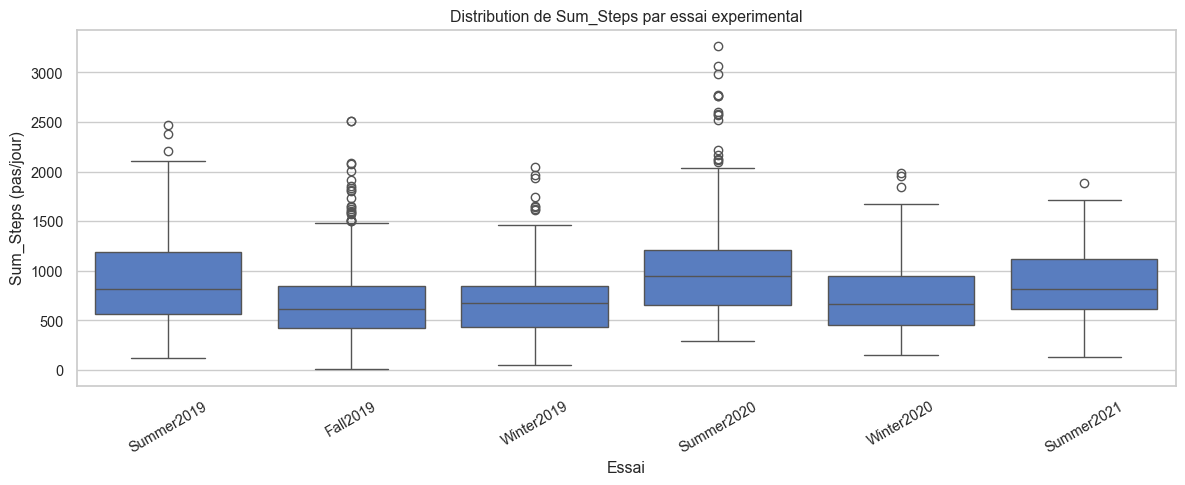

In [21]:
# 6a. Distribution de Sum_Steps par essai
fig, ax = plt.subplots(figsize=(12, 5))
order = ['Summer2019', 'Fall2019', 'Winter2019', 'Summer2020', 'Winter2020', 'Summer2021']
sns.boxplot(data=full_df, x='dataset', y='Sum_Steps', order=order, ax=ax)
ax.set_xlabel('Essai')
ax.set_ylabel('Sum_Steps (pas/jour)')
ax.set_title('Distribution de Sum_Steps par essai experimental')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

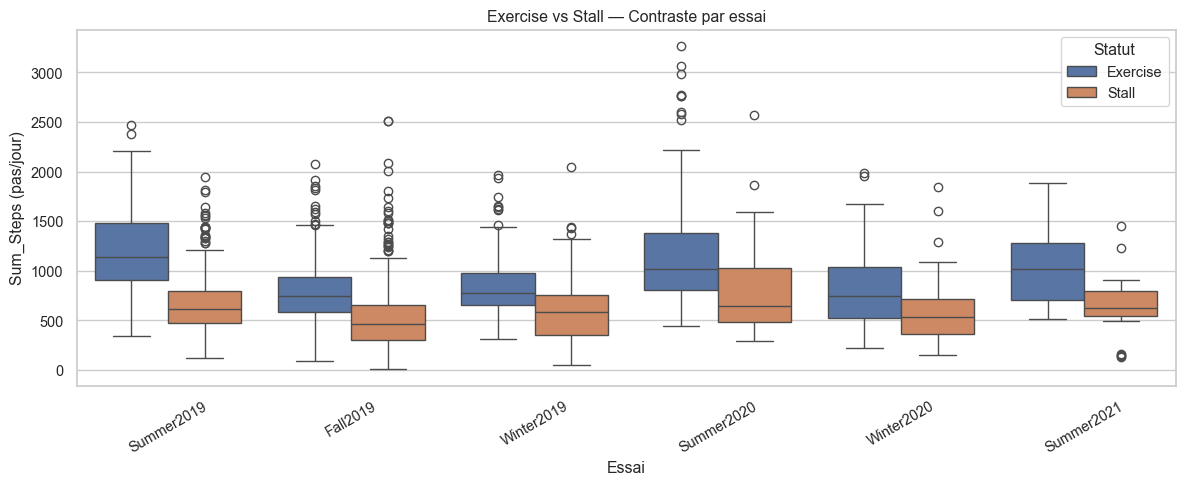


Contrastes Exercise vs Stall:


,mean_Exercise,mean_Stall,median_Exercise,median_Stall,count_Exercise,count_Stall,diff_mean,diff_pct
dataset,,,,,,,,
Fall2019,790.0,539.9,742.0,466.0,359,349,250.1,46.3
Summer2019,1189.5,678.6,1139.5,618.5,230,276,510.9,75.3
Summer2020,1188.2,784.6,1021.0,644.0,159,84,403.6,51.4
Summer2021,1022.9,643.0,1018.0,629.0,37,24,379.9,59.1
Winter2019,840.5,590.9,774.0,588.0,150,260,249.6,42.2
Winter2020,802.6,580.4,748.0,529.0,192,94,222.2,38.3


In [23]:
# 6b. Exercise vs Stall par essai
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=full_df, x='dataset', y='Sum_Steps', hue='exercise_status',
            order=order, ax=ax, palette={'Exercise': '#4C72B0', 'Stall': '#DD8452'})
ax.set_xlabel('Essai')
ax.set_ylabel('Sum_Steps (pas/jour)')
ax.set_title('Exercise vs Stall — Contraste par essai')
ax.legend(title='Statut')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Tableau des contrastes
contrasts = (
    full_df.groupby(['dataset', 'exercise_status'])['Sum_Steps']
    .agg(['mean', 'median', 'count'])
    .round(1)
    .unstack('exercise_status')
)
contrasts.columns = [f'{stat}_{grp}' for stat, grp in contrasts.columns]
contrasts['diff_mean'] = (contrasts['mean_Exercise'] - contrasts['mean_Stall']).round(1)
contrasts['diff_pct'] = ((contrasts['diff_mean'] / contrasts['mean_Stall']) * 100).round(1)
print("\nContrastes Exercise vs Stall:")
contrasts

# 6c. Contexte d'acces (Outdoor / Indoor / Stall)
fig, ax = plt.subplots(figsize=(10, 5))
ctx_order = ['Outdoor', 'Indoor', 'Stall', 'Autre']
ctx_present = [c for c in ctx_order if c in full_df['access_context'].values]
sns.boxplot(data=full_df, x='access_context', y='Sum_Steps', order=ctx_present, ax=ax,
            palette={'Outdoor': '#55A868', 'Indoor': '#4C72B0', 'Stall': '#DD8452', 'Autre': '#999999'})
ax.set_xlabel('Contexte')
ax.set_ylabel('Sum_Steps (pas/jour)')
ax.set_title('Sum_Steps par contexte d\'acces (tous essais)')
plt.tight_layout()
plt.show()

# Moyennes par contexte
print("\nMoyennes par contexte d'acces:")
full_df.groupby('access_context')['Sum_Steps'].agg(['count', 'mean', 'median']).round(1)

---
## 7. Design experimental: effets Size et Duration

Les essais Summer2019 et Winter2019 contiennent les colonnes `Size` (m2) et `Duration_per_day` (heures). L'article rapporte:
- grande aire > petite aire (+146 pas/jour)
- 2h > 1h (+84 pas/jour)

Verifions ces tendances dans les donnees brutes.

Moyennes par Size (m2):
        mean  count
Size               
20.0   974.0     84
40.0   983.5     98
60.0  1079.0    101
80.0  1159.6     97

Moyennes par Duration_per_day:
                    mean  count
Duration_per_day               
1.0               1011.2    195
2.0               1094.4    185


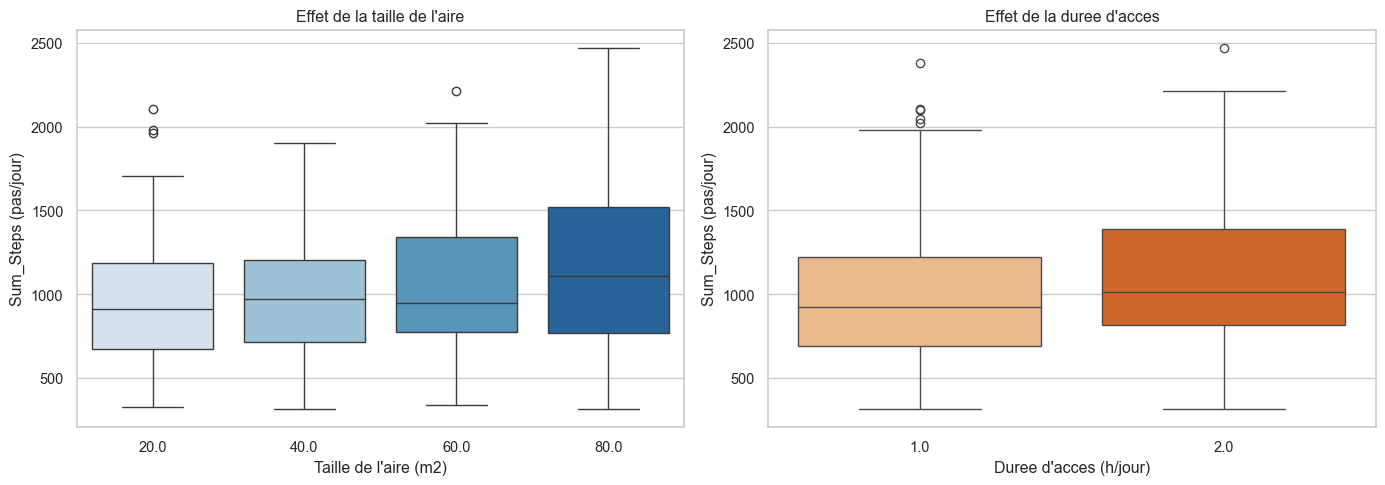

In [27]:
# Essais avec Size et Duration: Summer2019 et Winter2019
exercise_df = full_df[
    (full_df['exercise_status'] == 'Exercise') &
    (full_df['Size'].notna()) &
    (full_df['Duration_per_day'].notna())
].copy()

# Exclure les valeurs de Size anormalement petites (probablement la stall)
exercise_df = exercise_df[exercise_df['Size'] >= 10]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Effet Size
sns.boxplot(data=exercise_df, x='Size', y='Sum_Steps', ax=ax1, palette='Blues')
ax1.set_xlabel('Taille de l\'aire (m2)')
ax1.set_ylabel('Sum_Steps (pas/jour)')
ax1.set_title('Effet de la taille de l\'aire')

# Moyennes par Size
size_means = exercise_df.groupby('Size')['Sum_Steps'].agg(['mean', 'count']).round(1)
print("Moyennes par Size (m2):")
print(size_means)

# Effet Duration
if 'Duration_per_day' in exercise_df.columns and exercise_df['Duration_per_day'].nunique() > 1:
    sns.boxplot(data=exercise_df, x='Duration_per_day', y='Sum_Steps', ax=ax2, palette='Oranges')
    ax2.set_xlabel('Duree d\'acces (h/jour)')
    ax2.set_ylabel('Sum_Steps (pas/jour)')
    ax2.set_title('Effet de la duree d\'acces')

    dur_means = exercise_df.groupby('Duration_per_day')['Sum_Steps'].agg(['mean', 'count']).round(1)
    print("\nMoyennes par Duration_per_day:")
    print(dur_means)

plt.tight_layout()
plt.show()

---
## 8. Structure du design crossover (Trt_order)

La colonne `Trt_order` encode l'ordre de passage des traitements dans un design croise. Comprendre cette structure est essentiel pour la modelisation (effets d'ordre, effets de periode).

In [30]:
# Trt_order par essai
for name, df in datasets.items():
    if 'Trt_order' in df.columns:
        orders = df['Trt_order'].unique()
        n_cows_per_order = df.groupby('Trt_order')['Cow_ID'].nunique()
        print(f"\n{name}:")
        print(f"  Ordres: {sorted(orders, key=str)}")
        print(f"  Vaches par ordre:")
        for ord_val, n in n_cows_per_order.items():
            print(f"    {ord_val}: {n} vaches")
    else:
        print(f"\n{name}: pas de Trt_order")

# Interpretation des codes d'ordre
print("\n" + "="*60)
print("Interpretation probable des codes Trt_order:")
print("  Numeriques (1, 2, ...): ordre latin square (Summer/Winter 2019)")
print("  I-O, O-I: Indoor-first puis Outdoor, ou inverse (Winter 2020)")
print("  I-S, S-I: Indoor-first puis Stall, ou inverse")
print("  O-I-S, I-S-O, S-O-I: crossover a 3 periodes (Summer 2020)")
print("  A-C-S, C-A-S, S-A-C: Alternatif/Conventionnel/Stall (Summer 2021)")
print("  => Confirmer avec Tania/Marjorie")


Fall2019: pas de Trt_order

Summer2019:
  Ordres: ['1', '3', '4', '5', '6', '7', '8', 'S']
  Vaches par ordre:
    1: 1 vaches
    3: 1 vaches
    4: 1 vaches
    5: 1 vaches
    6: 1 vaches
    7: 1 vaches
    8: 1 vaches
    S: 8 vaches

Summer2020:
  Ordres: ['I-O-S', 'I-S-O', 'O-I-S', 'O-S-I', 'S-I-O', 'S-O-I']
  Vaches par ordre:
    I-O-S: 3 vaches
    I-S-O: 3 vaches
    O-I-S: 3 vaches
    O-S-I: 3 vaches
    S-I-O: 3 vaches
    S-O-I: 3 vaches

Summer2021:
  Ordres: ['A-C-S', 'A-S-C', 'C-A-S', 'C-S-A', 'S-A-C', 'S-C-A']
  Vaches par ordre:
    A-C-S: 1 vaches
    A-S-C: 1 vaches
    C-A-S: 1 vaches
    C-S-A: 1 vaches
    S-A-C: 1 vaches
    S-C-A: 1 vaches

Winter2019:
  Ordres: ['1', '2', '3', '5', '6', '8', '9', 'S']
  Vaches par ordre:
    1: 1 vaches
    2: 1 vaches
    3: 1 vaches
    5: 1 vaches
    6: 1 vaches
    8: 1 vaches
    9: 1 vaches
    S: 7 vaches

Winter2020:
  Ordres: ['I-O', 'I-S', 'O-I', 'O-S', 'S-I', 'S-O']
  Vaches par ordre:
    I-O: 5 vaches
    I-S:

---
## 9. Vaches partagees entre essais

Certaines vaches participent a plusieurs essais. C'est important pour la modelisation (effets aleatoires, structure de dependance).

In [33]:
# Quelles vaches apparaissent dans plusieurs essais?
cow_trials = {}
for name, df in datasets.items():
    for cow in df['Cow_ID'].unique():
        cow_trials.setdefault(cow, []).append(name)

multi_trial = {cow: trials for cow, trials in cow_trials.items() if len(trials) > 1}
print(f"Vaches dans un seul essai: {sum(1 for t in cow_trials.values() if len(t) == 1)}")
print(f"Vaches dans plusieurs essais: {len(multi_trial)}")

if multi_trial:
    print(f"\nDetail:")
    for cow, trials in sorted(multi_trial.items(), key=lambda x: -len(x[1])):
        print(f"  Cow {cow}: {', '.join(trials)}")

Vaches dans un seul essai: 70
Vaches dans plusieurs essais: 20

Detail:
  Cow 2062: Fall2019, Summer2019
  Cow 2081: Fall2019, Winter2019
  Cow 5854: Fall2019, Summer2019
  Cow 5865: Fall2019, Summer2019
  Cow 2063: Fall2019, Winter2019
  Cow 5857: Fall2019, Summer2019
  Cow 5862: Fall2019, Summer2019
  Cow 5871: Fall2019, Summer2019
  Cow 8500: Fall2019, Winter2019
  Cow 8525: Fall2019, Summer2019
  Cow 8536: Fall2019, Summer2019
  Cow 3678: Summer2020, Winter2020
  Cow 3681: Summer2020, Winter2020
  Cow 747: Summer2020, Winter2020
  Cow 780: Summer2020, Summer2021
  Cow 8731: Summer2020, Winter2020
  Cow 8734: Summer2020, Summer2021
  Cow 8735: Summer2020, Winter2020
  Cow 8742: Summer2020, Summer2021
  Cow 8764: Summer2020, Summer2021


---
## 10. Nombre d'observations par vache (equilibre du design)

Un design experimental equilibre devrait montrer un nombre similaire d'observations par vache dans chaque essai. Un desequilibre peut indiquer des donnees manquantes ou des retraits du protocole.

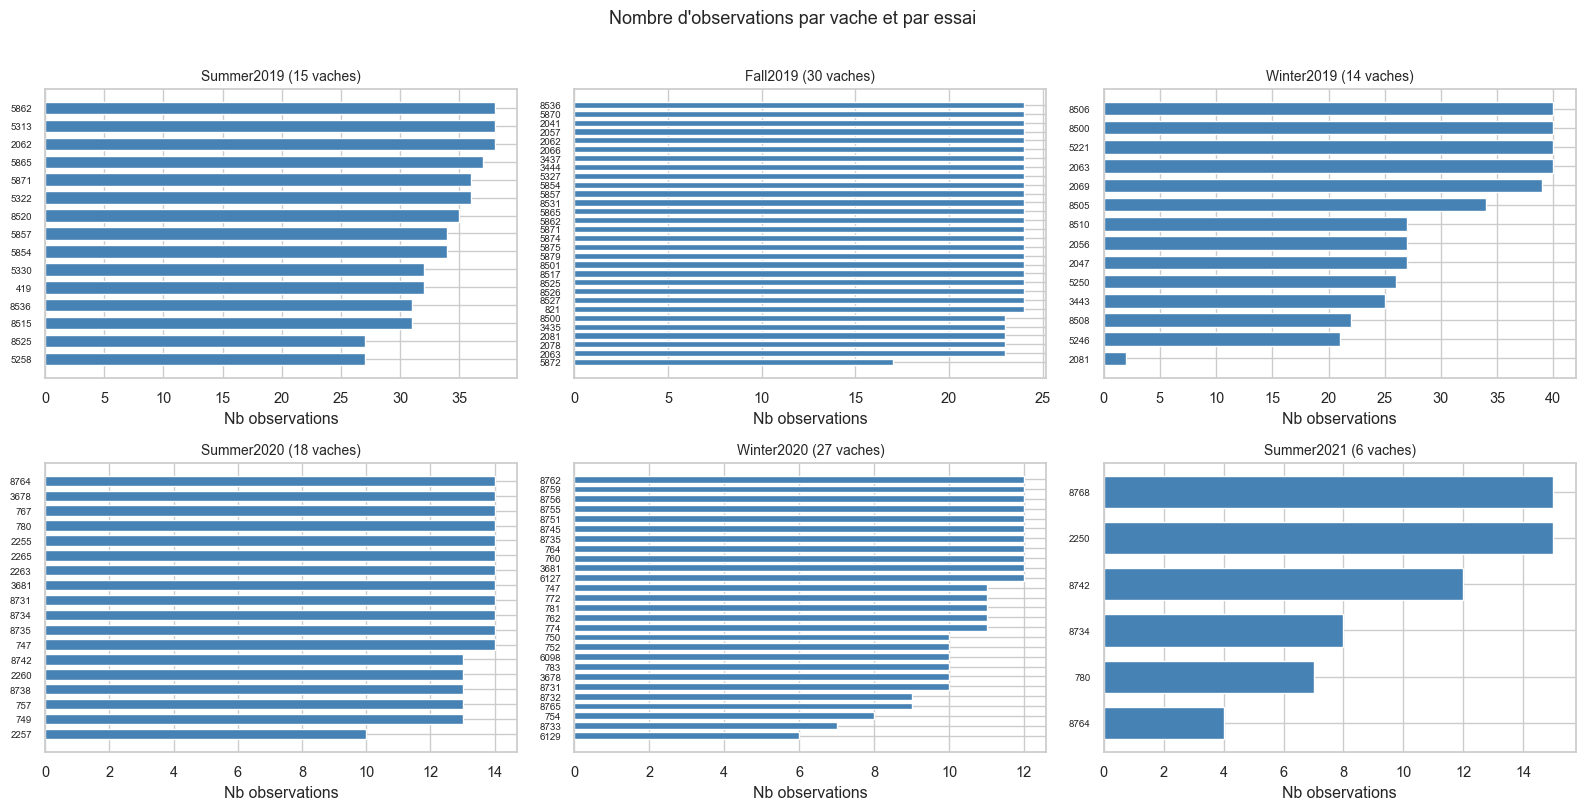

Fall2019       : min= 17  max= 24  moy=23.6  ecart-type=1.3
Summer2019     : min= 27  max= 38  moy=33.7  ecart-type=3.7
Summer2020     : min= 10  max= 14  moy=13.5  ecart-type=1.0
Summer2021     : min=  4  max= 15  moy=10.2  ecart-type=4.5
Winter2019     : min=  2  max= 40  moy=29.3  ecart-type=10.7
Winter2020     : min=  6  max= 12  moy=10.6  ecart-type=1.6


In [36]:
# Observations par vache dans chaque essai
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(order):
    ax = axes[i]
    df = datasets[name]
    obs_per_cow = df.groupby('Cow_ID').size().sort_values()
    ax.barh(range(len(obs_per_cow)), obs_per_cow.values, color='steelblue', height=0.7)
    ax.set_yticks(range(len(obs_per_cow)))
    ax.set_yticklabels(obs_per_cow.index, fontsize=7)
    ax.set_xlabel('Nb observations')
    ax.set_title(f'{name} ({len(obs_per_cow)} vaches)', fontsize=10)

plt.suptitle('Nombre d\'observations par vache et par essai', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Stats de desequilibre
for name, df in datasets.items():
    obs = df.groupby('Cow_ID').size()
    print(f"{name:15s}: min={obs.min():3d}  max={obs.max():3d}  moy={obs.mean():.1f}  ecart-type={obs.std():.1f}")

---
## 11. Synthese des constats d'audit

### Structure
- **6 fichiers CSV** correspondant aux 6 essais de l'article (Summer2019 a Summer2021)
- **2214 observations**, **90 vaches uniques** (article: 141), **110 presences-vache**
- Certaines vaches participent a plusieurs essais (structure de dependance)

### Qualite
- **0 valeur manquante** dans les CSV disponibles
- **13 doublons exacts** (Fall2019: 9, Winter2019: 3, Summer2020: 1) — a verifier
- Quelques valeurs extremes basses (Sum_Steps <= 50): artefacts de capteur ou jours sans port?
- Desequilibre du nombre d'observations par vache selon les essais

### Heterogeneite des schemas
- Les colonnes `Trt`, `Trt_details`, `Trt_order` changent de sens entre essais
- `Size` et `Duration_per_day` ne sont presentes que dans Summer2019, Winter2019 (et Size dans Summer2021)
- `Period` et `Week_Period` n'apparaissent que dans les essais 2020-2021
- `Fall2019` a un `Block` numerique + `Block.1` en texte, les autres ont `Block` en texte

### Coherence avec l'article
- Les contrastes descriptifs Exercise vs Stall sont coherents avec le papier
- L'effet Outdoor > Indoor > Stall est visible dans les donnees brutes
- Les tendances Size et Duration vont dans le bon sens (a confirmer par modelisation)

### Design experimental
- Summer/Winter 2019: latin square classique avec tailles et durees variables
- Winter 2020: crossover 2 periodes (I-O, O-I, I-S, S-I)
- Summer 2020: crossover 3 periodes (O-I-S, I-S-O, S-O-I)
- Summer 2021: crossover 3 periodes Alternatif/Conventionnel/Stall
- Fall 2019: pas de `Trt_order` — design different?

---
## 12. Questions pour la rencontre avec Tania et Marjorie (2 avril 2026)

### A. Sur les donnees manquantes par rapport a l'article
1. L'article mentionne **141 vaches**, mais les CSV n'en contiennent que **90 uniques**. Les 51 vaches manquantes sont-elles dans des fichiers non encore transmis, ou bien exclues apres filtrage?
2. Chaque ligne represente-t-elle **un jour d'observation** pour une vache? Ou une autre unite (session, semaine, bloc)?
3. Quels **criteres d'exclusion** ont ete appliques dans l'article (vaches boiteuses, capteur defaillant, etc.)?

### B. Sur la structure des variables
4. Pourquoi `Fall2019` est-il structure differemment des autres (pas de `Trt_details`, pas de `Trt_order`, double colonne `Block`/`Block.1`)? Est-ce un design experimental different?
5. Dans Summer2021, `Trt_details` prend les valeurs **Alternatif** et **Conventionnel** — a quoi font reference ces termes exactement? Type de sol? Mode d'acces?
6. Les valeurs `Size = 2.6` et `Size = 2.9` dans Summer2021: s'agit-il de la **surface de la stall** elle-meme (en m2), ou d'une aire d'exercice reduite?
7. La colonne `Week` est-elle la **semaine experimentale** (1 = debut du protocole) ou la semaine calendaire?

### C. Sur le design experimental
8. Pour les essais 2019 (Summer, Winter): le design est-il un **latin square complet**? Combien de combinaisons Size x Duration ont ete testees?
9. Pour les essais 2020-2021: les codes `Trt_order` (ex: I-O, O-I-S) representent-ils l'**ordre de passage** des traitements dans un crossover? Quelle est la duree de chaque **periode**?
10. Y a-t-il eu une **periode de washout** entre les traitements dans les designs croises?
11. Les `Block` representent-ils des **groupes de vaches appariees** (par parite, DIM, etc.)? Quels criteres d'appariement?

### D. Sur les doublons et valeurs extremes
12. Les **13 doublons exacts** (meme Cow_ID, meme Week, memes valeurs) sont-ils normaux? S'agit-il de jours differents dans la meme semaine qui ont les memes valeurs par coincidence, ou de vrais doublons?
13. Certaines observations ont un `Sum_Steps` tres bas (ex: 6 pas dans Fall2019). Ces valeurs representent-elles un **jour ou le capteur n'a pas ete porte**, un jour de maladie, ou une vraie mesure?

### E. Sur les donnees complementaires attendues
14. Les **donnees environnementales** (temperature, humidite): sont-elles enregistrees en continu avec horodatage? A quelle frequence? Sont-elles alignables jour par jour avec les CSV actuels?
15. Les **observations comportementales**: sous quelle forme? Ethogramme code? Video annotee? Avec quel pas de temps?
16. Les **signaux accelerometres bruts** (IceTag, 1-minute intervals mentionnes dans l'article): sont-ils disponibles ou seulement l'agregat `Sum_Steps`?
17. Y a-t-il d'autres **variables reponses** mesurees et non presentes ici (ex: duree de coucher, nombre de transitions debout/couche, asymetrie de pas)?

### F. Sur les objectifs du projet
18. L'objectif principal est-il **explicatif** (comprendre comment l'environnement affecte le comportement) ou **predictif** (pouvoir predire le comportement a partir de l'environnement)?
19. Le notebook final doit-il etre utilisable par **des chercheurs non-informaticiens** de l'equipe? Si oui, quel niveau d'interactivite est souhaite?
20. Au-dela de la reproduction des resultats de l'article, qu'est-ce que l'equipe espere decouvrir de **nouveau** avec cette analyse?

# 6d. Evolution temporelle: Sum_Steps par semaine et par essai
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for i, name in enumerate(order):
    ax = axes[i]
    df = datasets[name]
    weekly = df.groupby('Week')['Sum_Steps'].agg(['mean', 'std']).reset_index()
    ax.errorbar(weekly['Week'], weekly['mean'], yerr=weekly['std'], marker='o',
                capsize=3, linewidth=1.5, markersize=4)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Semaine')
    if i % 3 == 0:
        ax.set_ylabel('Sum_Steps (moy +/- std)')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.suptitle('Evolution de Sum_Steps par semaine et par essai', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()